# Computing the equilibrium Z projecttors

Defined as

$P_z^n = \prod (1+\sigma^z_i)/2 $

$\sigma_i^z = 1- 2 c_i^\dagger c_i$ = $-B_i A_i$

In [1]:
import sys
import os
sys.path.append("../../src/")
#Imports
#import single_particle_sector as sps
import kblock_ising_model as kb
import numpy as np
import scipy as sp
import numpy.linalg as la
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot, scatter
from collections import Counter
from tqdm import tqdm

##Personal Imports##

from numpy import pi, cos, sin, exp, log, sqrt, array


#Correlation Function
#Definition of this comes from sachdev
def Dn(n):
    return 2/pi/(1-2*n)


###Typical Sigma General Function

def BA(j):
    return Dn(-j+1)



In [150]:
sigma_general([1,2,3])

np.float64(0.48926772236438937)

In [ ]:

def sigma_general(indices):
    def remove_duplicates_in_pairs(vec):
      unique_vals, counts = np.unique(vec, return_counts=True)
      filtered_vals = unique_vals[counts % 2 != 0]
      return filtered_vals.tolist()
    #Sigma matrices on different sites commute
    indices = np.sort(indices)
    #Remove any duplicates as sigma_x^2 = 1
    indices = remove_duplicates_in_pairs(indices)

    #Get string lengths
    A_coords = np.array(indices)
    B_coords = np.array(indices)
    N = len(indices)
    C = np.zeros((N,N))
    for nx in range(N):
        for ny in range(N):
            Bx = B_coords[nx]
            Ay = A_coords[ny]
            Nd = Bx-Ay+1
            C[nx,ny] = -Dn(Nd)
    return np.linalg.det(C)

#Typical Pn function

   


3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


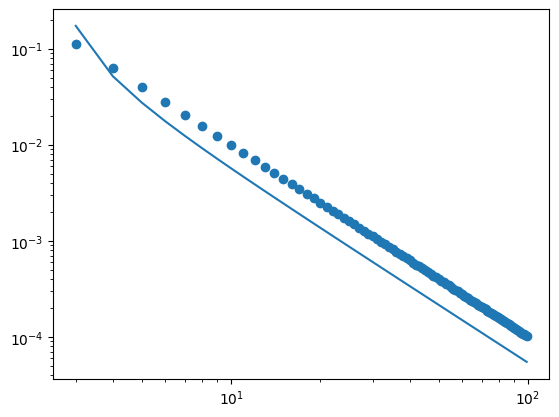

In [3]:
dat=[]
x = np.arange(3,100)
for xi in x:
    print(xi)
    s = sigma_general([0,1,2,xi,xi+1,xi+2])
    s0 =sigma_general([0,1,2])
    dat+=[s-s0**2]
dat=np.array(dat)
plt.loglog(x,dat)
plt.scatter(x,x**(-2.))

In [4]:
#Typical Pn function
def P_n(n):
    """
    P_n scales directly with the number of terms since even small odd sigma correlations need larger support to calcualte.
    Taking out odd terms works to make easier, but scaling is still 2^n.
    Minor improvements can still be had though.
    """
    #For most cases we use periodic boundary conditions
    #That said, watch out for this definition of indices
    indices = [i for i in range(0,n)]
    terms = kb.all_combinations(indices)

    ###
    x_c = []
    for a in terms[1:]:
        a = np.array(a)
        x_c.append(tuple(a - a[0]))  # convert to tuple for hashing
    

    counter = Counter(x_c)

    # Extract vecs and counts as separate arrays/lists
    vecs = list(counter.keys())
    counts = np.array(list(counter.values()))

    ##
    dat = []

    for term in range(len(vecs)):
        indices = vecs[term]
        degen = counts[term]

        dat.append(sigma_general(indices)*degen)
    dat.append(1)
    #All terms have equal weight. 
    return np.sum(dat)/2**n



In [5]:
#P_n correlations do not calculate connected correlator at all
def P_n_correlations(n,l):
    #Term 1 
    indices = [i for i in range(0,n)]
    #Term 2 
    indices +=[i for i in range(n+l-1,2*n+l-1)]
    terms = kb.all_combinations(indices)
   # print(terms)
     ###
    x_c = []
    for a in terms[1:]:
      
        a = np.array(a)
        x_c.append(tuple(a - a[0]))  # convert to tuple for hashing
    counter = Counter(x_c)

    # Extract vecs and counts as separate arrays/lists
    vecs = list(counter.keys())
    counts = np.array(list(counter.values()))
    #
    dat = []
    for term in range(len(vecs)):
        indices = vecs[term]
        degen = counts[term]

        dat.append(sigma_general(indices)*degen)
    dat.append(1)
    #All terms have equal weight. 

    return np.sum(dat)/2**(2*n)#,terms


In [6]:
x= np.arange(1,200)

In [7]:
from tqdm import tqdm
dat = []
for n in tqdm(range(1,10+1)):
   dat += [ P_n_correlations(n,xi) -P_n(n)**2 for xi in x]


100%|██████████| 10/10 [16:59:02<00:00, 6114.23s/it]  


In [167]:
x

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 18

ValueError: x and y must have same first dimension, but have shapes (199,) and (0,)

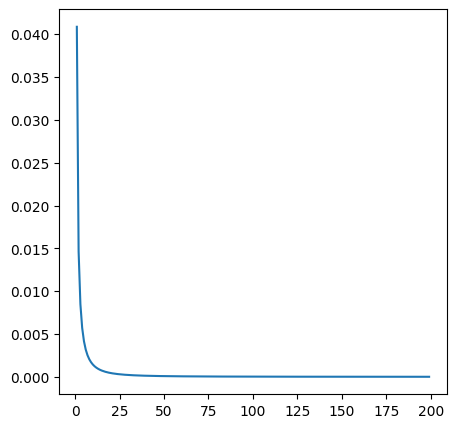

In [168]:
plt.figure(figsize=(5, 5))  # Square figure

for i in range(1,10+1,3):
    plot(x[:199],dat[199*(i-1):199*(i)],label=f"n = {i}")
#plot(x,dat[199*(10-1):199*(10)],label=f"n = {10}")
#plt.loglog()
plt.xlim(x[0],30)
plt.ylim(10**(-6),10**(-1.5))
plt.plot(x,dat[1]*x**(-2.)/x[1]**(-2.),color="black",ls="--",label=r"$x^{-2}$")
plt.plot(x,dat[1]*x**(-1.)/x[1]**(-1.),color="black",ls=":",label=r"$x^{-1}$")
plt.legend()
plt.xlabel(r"$r$")
plt.ylabel(r"$\langle P^z_n(0) P^z_n(r) \rangle_{cc} $")

file_name = "connected_correlator_z_projectors_full_3.png"
folder_name = "equilibrium_zproj_plots/"
#plt.savefig(folder_name+file_name)

In [60]:
real_dat =[]
for i in range(1,10+1,1):
    y= dat[199*(i-1):199*(i)]
    real_dat.append(y)
#plot(x,dat[199*(10-1):199*(10)],label=f"n = {10}")


In [74]:
folder_name = "equilibrium_zproj_plots"

# Create the folder if it doesn't exist
if not os.path.exists(folder_name):
    os.makedirs(folder_name)


In [66]:
for i in range(1,10+1,1):
    y= dat[199*(i-1):199*(i)]

    file_name = f"/ZZ_corr_connected_n{i}_r00-199.npy"

    np.save(folder_name+file_name,y)

In [163]:
x = np.arange(1,400)

In [164]:

dat= [P_n_correlations(4,xi)-P_n(4)**2 for xi in x]

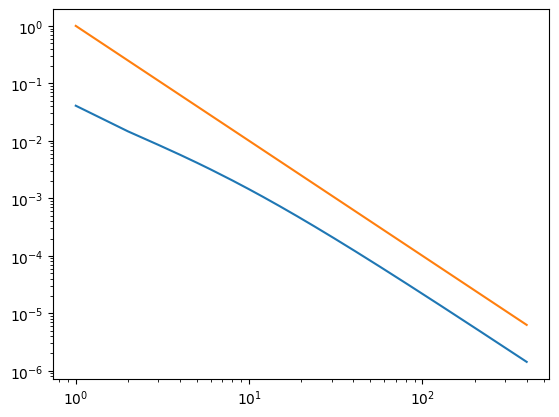

In [165]:
plot(x,dat)
plt.loglog()
plt.plot(x,x**(-2.))